# 05 - Artificial Neural Network (MLP)

**Owner:** Member E

**Inputs:** preprocessed splits produced by `00_eda_and_preprocessing.ipynb`
(`artifacts/splits/splits.npz`). Do not re-split or re-scale here.

**Outputs:** `artifacts/results/ann.json`,
`artifacts/models/ann.joblib`,
plus ROC / PR / confusion-matrix PNGs in `figures/`.

**Why this model**

A Multi-Layer Perceptron (MLP) is our **neural network** model. It learns non-linear feature
interactions through multiple hidden layers and applies backpropagation with the Adam optimiser.
Unlike tree models, MLPs are sensitive to feature scale (already handled in notebook 00) and
can capture complex decision boundaries. `sklearn.neural_network.MLPClassifier` does not
support `class_weight` natively, so:
- **Variant A** — plain MLP (no explicit imbalance handling), serving as an unweighted baseline.
- **Variant B** — SMOTE oversampling on training folds only (via `imblearn.pipeline.Pipeline`).

The structure below is identical across the five model notebooks:
1. Load shared splits.
2. **Variant A** — model with built-in or baseline imbalance approach.
3. **Variant B** — SMOTE oversampling on training folds only.
4. Pick the variant with the higher CV F1, refit, evaluate on the held-out test set.
5. Save the result JSON + the fitted model.


## 1. Setup & load shared splits

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import load_splits
from src.tuning import grid_search, random_search, CV
from src.evaluation import (
    evaluate, save_results, print_metric_table,
    plot_confusion, plot_roc, plot_pr, _scores,
)

SPLITS_DIR  = PROJECT_ROOT / "artifacts" / "splits"
MODELS_DIR  = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "results"
FIG_DIR     = PROJECT_ROOT / "figures"
for d in (MODELS_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

data = load_splits(SPLITS_DIR)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
feature_names   = data["feature_names"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"train fraud rate: {y_train.mean():.4f}, test fraud rate: {y_test.mean():.4f}")

X_train: (7430, 45), X_test: (1858, 45)
train fraud rate: 0.1783, test fraud rate: 0.1781


## 2. Variant A: Plain MLP (no explicit imbalance handling)

MLPClassifier does not expose a `class_weight` parameter, so this variant trains
on the natural class distribution. We tune architecture depth/width, regularisation
strength (`alpha`), and activation function.

In [2]:
from sklearn.neural_network import MLPClassifier

estimator_plain = MLPClassifier(
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
)

grid_plain = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "activation":         ["relu", "tanh"],
    "alpha":              [0.001, 0.01],
}

search_plain = grid_search(estimator_plain, grid_plain)
search_plain.fit(X_train, y_train)
print(f"Variant A best CV F1: {search_plain.best_score_:.4f}  params: {search_plain.best_params_}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

...

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

Variant A best CV F1: 0.8580  params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (128, 64)}


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

## 3. Variant B: SMOTE + MLP

SMOTE generates synthetic minority-class points inside each CV training fold
before the MLP sees them, effectively teaching the network on a balanced dataset
without touching the test set.

In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipe_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   MLPClassifier(
        solver="adam",
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    )),
])

grid_smote = {
    "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "clf__activation":         ["relu", "tanh"],
    "clf__alpha":              [0.001, 0.01],
}

search_smote = grid_search(pipe_smote, grid_smote)
search_smote.fit(X_train, y_train)
print(f"Variant B best CV F1: {search_smote.best_score_:.4f}  params: {search_smote.best_params_}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/pyth

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

...

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

Variant B best CV F1: 0.8645  params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64)}


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 4. Pick the better variant, refit & evaluate on test

In [4]:
variants = {
    "no_rebalancing": search_plain,
    "smote":          search_smote,
}
best_variant = max(variants, key=lambda k: variants[k].best_score_)
best_search  = variants[best_variant]
best_model   = best_search.best_estimator_

other = "smote" if best_variant == "no_rebalancing" else "no_rebalancing"
print(f"\nWinning variant: {best_variant}")
print(f"  CV F1 (winning):       {best_search.best_score_:.4f}")
print(f"  CV F1 (other variant): {variants[other].best_score_:.4f}")
print(f"  Best params:           {best_search.best_params_}")

results = evaluate(
    best_model,
    X_train, y_train, X_test, y_test,
    model_name="ann",
    best_params=best_search.best_params_,
    imbalance_strategy=best_variant,
)
print_metric_table(results)

save_results(results, RESULTS_DIR / "ann.json")
joblib.dump(best_model, MODELS_DIR / "ann.joblib")
print(f"\nSaved -> artifacts/results/ann.json + artifacts/models/ann.joblib")


Winning variant: smote
  CV F1 (winning):       0.8645
  CV F1 (other variant): 0.8580
  Best params:           {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64)}

=== ann (smote) ===
Best params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64)}
metric                   train      test
accuracy                0.9720    0.9510
balanced_accuracy       0.9706    0.9276
precision               0.8854    0.8429
recall                  0.9683    0.8912
f1                      0.9250    0.8664
roc_auc                 0.9958    0.9771
pr_auc                  0.9824    0.9447
Confusion matrix (test):
[[1472   55]
 [  36  295]]

Saved -> artifacts/results/ann.json + artifacts/models/ann.joblib


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

## 5. Diagnostic plots

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


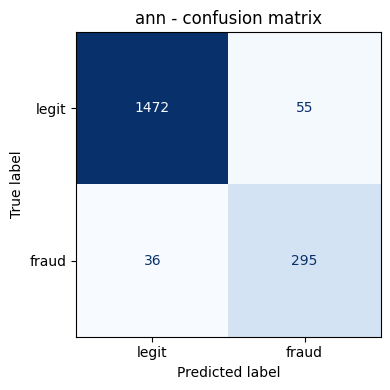

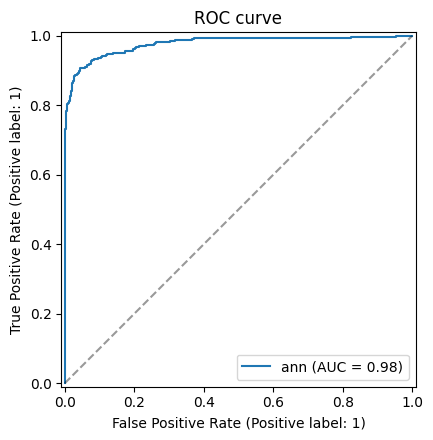

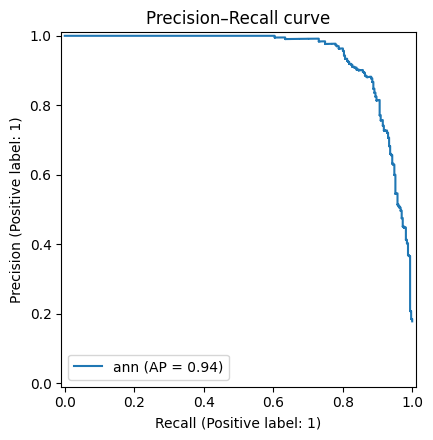

In [5]:
y_pred  = best_model.predict(X_test)
y_score = _scores(best_model, X_test)

fig_cm = plot_confusion(y_test, y_pred, title=f"{results['model_name']} - confusion matrix")
fig_cm.savefig(FIG_DIR / "ann_confusion.png", bbox_inches="tight")
plt.show()

if y_score is not None:
    fig_roc = plot_roc(y_test, y_score, label="ann")
    fig_roc.savefig(FIG_DIR / "ann_roc.png", bbox_inches="tight")
    plt.show()

    fig_pr = plot_pr(y_test, y_score, label="ann")
    fig_pr.savefig(FIG_DIR / "ann_pr.png", bbox_inches="tight")
    plt.show()

## 6. Hand-off to the comparison notebook

`artifacts/results/ann.json` now contains:

```
model_name, imbalance_strategy, best_params,
train: {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
test:  {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
confusion_matrix_test
```

`06_comparison_and_interpretation.ipynb` will read this file (alongside the
other four) to build the comparison table and overlay the ROC / PR curves.